# Chowdeck — Machine Learning: Dự đoán Đơn Giá trị cao

Xây dựng model Random Forest Classifier dự đoán 1 đơn hàng có thuộc nhóm giá trị cao hay không, dựa trên các yếu tố ngữ cảnh (nhà hàng, nhóm món, thời gian, khu vực, rating). Mục tiêu: tìm yếu tố nào ảnh hưởng mạnh nhất đến giá trị đơn hàng khi xét đồng thời (đa biến), bổ sung cho phân tích tương quan đơn biến ở Bước 6.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import shap

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ĐƯỜNG DẪN

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent
CLEAN_PATH = BASE_DIR / 'data' / 'clean' / 'chowdeck_clean.csv'
CHARTS_DIR = BASE_DIR / 'outputs' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH

In [3]:
df = pd.read_csv(CLEAN_PATH, parse_dates=['Order Received', 'Order Delivered'])
print("Shape dữ liệu:", df.shape)

Shape dữ liệu: (3061, 33)


## 2. TẠO BIẾN MỤC TIÊU (TARGET): ĐƠN GIÁ TRỊ CAO HAY THẤP

In [4]:
median_subtotal = df['Sub Total'].median()
df['high_value'] = (df['Sub Total'] > median_subtotal).astype(int)
print(f"\nNgưỡng median Sub Total: ₦{median_subtotal:,.0f}")
print(f"Phân bố target: {df['high_value'].value_counts().to_dict()} "
      f"(0 = giá trị thấp, 1 = giá trị cao)")


Ngưỡng median Sub Total: ₦5,000
Phân bố target: {0: 1685, 1: 1376} (0 = giá trị thấp, 1 = giá trị cao)


## 3. CHỌN FEATURES (CHỈ DÙNG YẾU TỐ NGỮ CẢNH, KHÔNG DÙNG UNIT PRICE/QUANTITY)

In [5]:
feature_cols_categorical = ['Order Category', 'Shop Name', 'order_dayofweek', 'Delivery Location']
feature_cols_numeric = ['order_hour', 'Distance (km)', 'Rating', 'prep_time_min', 'delivery_time_min']

model_df = df[feature_cols_categorical + feature_cols_numeric + ['high_value']].dropna()
print(f"\nSố dòng dùng để train (sau khi bỏ dòng thiếu dữ liệu): {len(model_df)} / {len(df)}")


Số dòng dùng để train (sau khi bỏ dòng thiếu dữ liệu): 3061 / 3061


## 4. MÃ HÓA BIẾN PHÂN LOẠI (Label Encoding)

In [6]:
encoders = {}
for col in feature_cols_categorical:
    le = LabelEncoder()
    model_df[col + '_enc'] = le.fit_transform(model_df[col])
    encoders[col] = le

feature_cols_final = [c + '_enc' for c in feature_cols_categorical] + feature_cols_numeric
X = model_df[feature_cols_final]
y = model_df['high_value']

## 5. CHIA TRAIN/TEST (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} dòng | Test: {len(X_test)} dòng")


Train: 2448 dòng | Test: 613 dòng


## 6. HUẤN LUYỆN MODEL RANDOM FOREST

In [8]:
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

## 7. ĐÁNH GIÁ MODEL


=== KẾT QUẢ MODEL CHOWDECK ===
Accuracy:  0.777
Precision: 0.833
Recall:    0.630
F1-score:  0.718

So sánh với baseline (đoán ngẫu nhiên 50/50): model này TỐT HƠN đoán ngẫu nhiên


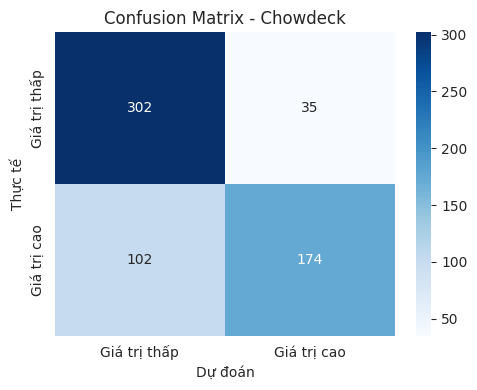

In [9]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n=== KẾT QUẢ MODEL CHOWDECK ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"\nSo sánh với baseline (đoán ngẫu nhiên 50/50): model này "
      f"{'TỐT HƠN' if acc > 0.55 else 'KHÔNG tốt hơn nhiều so với'} đoán ngẫu nhiên")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Giá trị thấp', 'Giá trị cao'],
            yticklabels=['Giá trị thấp', 'Giá trị cao'])
plt.title('Confusion Matrix - Chowdeck')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_confusion_matrix_chowdeck.png', dpi=120)
plt.show()
plt.close()

## 8. FEATURE IMPORTANCE - KẾT QUẢ QUAN TRỌNG NHẤT


=== Feature Importance (Chowdeck) ===
Order Category_enc       0.338922
Shop Name_enc            0.225300
Distance (km)            0.095732
delivery_time_min        0.089172
order_hour               0.066627
prep_time_min            0.063978
Delivery Location_enc    0.046413
order_dayofweek_enc      0.043582
Rating                   0.030274
dtype: float64


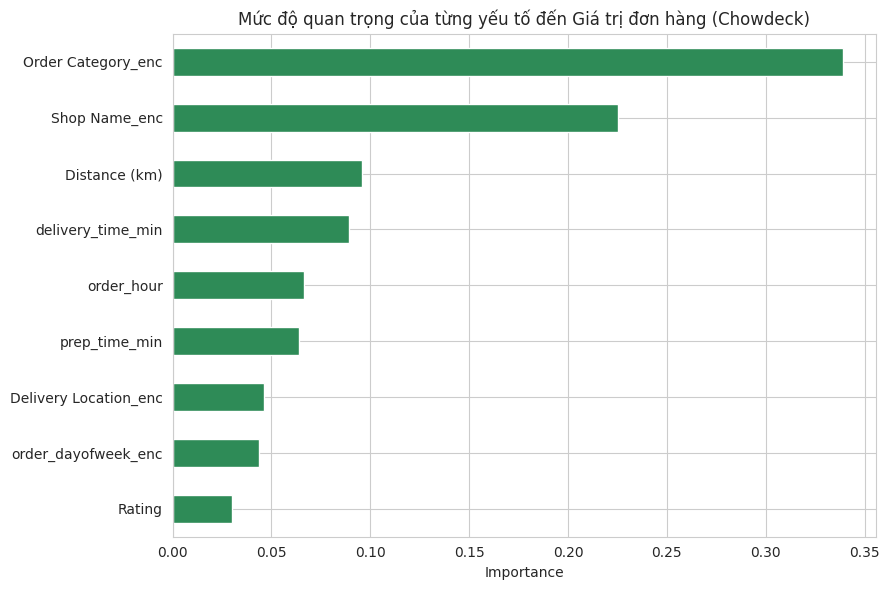

In [10]:
importance = pd.Series(model.feature_importances_, index=feature_cols_final).sort_values(ascending=False)
print("\n=== Feature Importance (Chowdeck) ===")
print(importance)

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color='seagreen')
plt.title('Mức độ quan trọng của từng yếu tố đến Giá trị đơn hàng (Chowdeck)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_feature_importance_chowdeck.png', dpi=120)
plt.show()
plt.close()


## 9. CROSS-VALIDATION (5-FOLD) - KIỂM TRA ĐỘ ỔN ĐỊNH CỦA MODEL

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("\n=== Cross-Validation (5-fold) - Chowdeck ===")
print(f"Accuracy từng fold: {np.round(cv_scores, 3)}")
print(f"Accuracy trung bình: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"So với Accuracy đo 1 lần trên Test set ({acc:.3f}): "
      f"{'nhất quán, đáng tin cậy' if abs(cv_scores.mean() - acc) < 0.05 else 'có chênh lệch, cần xem lại'}")


=== Cross-Validation (5-fold) - Chowdeck ===
Accuracy từng fold: [0.75  0.771 0.778 0.75  0.763]
Accuracy trung bình: 0.762 (+/- 0.011)
So với Accuracy đo 1 lần trên Test set (0.777): nhất quán, đáng tin cậy


## 10. SHAP VALUES - GIẢI THÍCH CHIỀU ẢNH HƯỞNG CỦA TỪNG YẾU TỐ

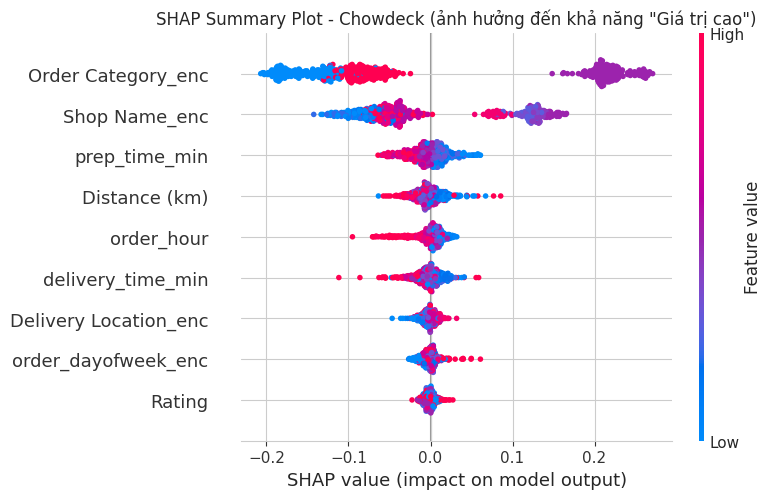


=== HOÀN TẤT MODEL ML CHOWDECK (đã nâng cấp: Cross-Validation + SHAP) ===


In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap_values_high = shap_values[:, :, 1]

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_high, X_test, feature_names=feature_cols_final, show=False)
plt.title('SHAP Summary Plot - Chowdeck (ảnh hưởng đến khả năng "Giá trị cao")')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_shap_summary_chowdeck.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

print("\n=== HOÀN TẤT MODEL ML CHOWDECK (đã nâng cấp: Cross-Validation + SHAP) ===")